# 07. Game-model refinement (M3b): a Kalman filter, week-varying weights, and a better QB term

This notebook walks through M3b (`context/ml-m3b-method.md`) and reads its results from the experiment registry
(`scripts/ml_m3b.py dev`). It covers:

1. **The Kalman filter from first principles**, on a two-team toy you can check by hand.
2. **The real filter**: its tuned settings, what team strength looks like over time, and how it scores on its own.
3. **Week-varying weights (C1)**: letting the model lean on Elo early in the season.
4. **QB improvements (C3)**: CPOE, an experience-based prior, and aging.
5. **The ladder**: every step against A4s on the same 3,450 development games, and the one-SE pick.

Everything here is development data (2006-2019). Nothing reads 2020-2025.

In [1]:
import sys, json
from pathlib import Path

ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "nflelo").is_dir())
sys.path.insert(0, str(ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from nflelo.ml import asof, data as D, registry
from nflelo.ml.eval import calibration
from nflelo.ml.features import kalman as kf, qb

plt.rcParams.update({"figure.figsize": (9, 3.6), "axes.spines.top": False, "axes.spines.right": False,
                     "axes.grid": True, "grid.alpha": 0.25, "font.size": 10})
pd.set_option("display.width", 160)
INK, ACCENT, MUTED, BAD = "#1f2a44", "#2f6fdf", "#9aa3b2", "#d1495b"

OUT = D.ML_DIR / "m3b"
frame = pd.read_parquet(OUT / "ladder_frame.parquet")
dev = frame[frame["dev"]].copy()
tune = json.loads((OUT / "tune.json").read_text())
runs = {}
for r in registry.load_runs():                      # newest run per step
    if r["label"] == "dev" and r["name"].startswith("m3b_"):
        runs[r["name"][4:]] = r
print(f"{len(dev):,} development games; {len(runs)} M3b dev runs in the registry.")

3,450 development games; 16 M3b dev runs in the registry.


## 1. The Kalman filter from first principles

A rating system has to answer two questions every week: *how good is each team*, and *how sure are we*. Elo only
tracks the first; its step size K is fixed. A Kalman filter tracks both. Each team's strength is a normal
distribution, a **mean** and a **variance**, and two steps repeat:

1. **Predict (time passes).** Teams change a little each week, so the mean stays put and the variance grows by
   `q` (the drift). Between seasons the mean is pulled toward average (multiplied by `gamma`) and extra variance is
   added: rosters turn over.
2. **Update (a game is played).** The game's margin is a noisy measurement of the strength difference plus home
   field: `margin = s_home - s_away + h + noise`, with noise SD `sigma` (about 12 to 13 points). The filter
   moves the means toward what the game says, by a fraction called the **gain**:

```
gain = Var(predicted margin) / (Var(predicted margin) + sigma^2)
```

When we are unsure about the teams (early season, big variance), the gain is large and one game moves the
ratings a lot. When we are sure, the gain is small. That is the adaptive K that Elo lacks, and it falls out of
Bayes' rule for normal distributions; nothing is hand-tuned.

### A two-team toy, by hand

Two teams, KC and BUF, both unknown at the start: mean 0, variance 36 (an SD of 6 points). No home field. KC
wins by 14. The predicted margin is 0 with variance 36 + 36 = 72, so the gain is 72 / (72 + 13^2) = 0.30. The
filter moves the *difference* by 0.30 x 14 = 4.2 points, split evenly: KC +2.1, BUF -2.1. Each variance falls
from 36 to 36 - 36^2 / 241 = 30.6. The two teams also become *positively* correlated: we learned about their
difference, not about each one separately, so if KC is really better than we think, BUF probably is too.

In [2]:
def toy_filter(margins, p0=36.0, q=0.5, sigma=13.0):
    """Two teams, the same matchup every week, written out with plain numbers (no library)."""
    m = np.zeros(2)                          # means: [KC, BUF]
    P = np.diag([p0, p0])                    # covariance
    a = np.array([1.0, -1.0])                # margin = s_KC - s_BUF + noise
    rows = []
    for w, y in enumerate(margins, start=1):
        if w > 1:
            P = P + q * np.eye(2)            # predict: a week passes
        pred, var = a @ m, a @ P @ a         # predicted margin and its variance
        gain = P @ a / (var + sigma ** 2)    # Kalman gain (one number per team)
        m = m + gain * (y - pred)            # update the means
        P = P - np.outer(gain, a @ P)        # update the covariance
        rows.append({"week": w, "margin": y, "pred": pred, "pred_sd": np.sqrt(var), "gain_KC": gain[0],
                     "KC": m[0], "BUF": m[1], "sd_KC": np.sqrt(P[0, 0]), "corr": P[0, 1] / P[0, 0]})
    return pd.DataFrame(rows)

toy = toy_filter([14, 3, -7, 10, 21, -3, 7, 0])
toy.round(3)

,week,margin,pred,pred_sd,gain_KC,KC,BUF,sd_KC,corr
0,1,14,0.000,8.485,0.149,2.091,-2.091,5.534,0.176
1,2,3,4.183,7.176,0.117,1.953,-1.953,5.302,0.298
2,3,-7,3.906,6.361,0.097,0.900,-0.900,5.164,0.388
3,4,10,1.799,5.801,0.083,1.581,-1.581,5.076,0.455
4,5,21,3.161,5.391,0.073,2.889,-2.889,5.020,0.508
5,6,-3,5.779,5.079,0.066,2.308,-2.308,4.984,0.550
6,7,7,4.616,4.835,0.061,2.453,-2.453,4.963,0.583
7,8,0,4.906,4.641,0.057,2.176,-2.176,4.952,0.611


Week 1 matches the hand calculation (KC +2.1, gain 0.15 per team = 0.30 on the difference, SD from 6.0 to
5.5). Later wins move the ratings less, because the variance has shrunk. The same numbers come out of the
project's filter, `nflelo/ml/features/kalman.py`, when it is given the same toy (home field switched off):

In [3]:
t = pd.DataFrame({"game_id": [f"g{i}" for i in range(8)], "season": 2022, "week": range(1, 9), "home": "KC",
                  "away": "BUF", "neutral": True, "margin": [14, 3, -7, 10, 21, -3, 7, 0], "kick_ns": range(8),
                  "ord": range(1, 9), "epa_margin": np.nan})
cfg = kf.KalmanConfig(q_week=0.5, sigma_m=13.0, p0=36.0, q_hfa=0.0)
res = kf.run_filter(t, cfg)
print("predicted margins, toy vs library:")
print(np.round(toy["pred"].to_numpy(), 4))
print(np.round(res.pred_mean, 4))
assert np.allclose(toy["pred"], res.pred_mean) and np.allclose(toy["pred_sd"], np.sqrt(res.pred_var))

predicted margins, toy vs library:
[0.     4.1826 3.9064 1.7995 3.1611 5.7786 4.616  4.9058]
[0.     4.1826 3.9064 1.7995 3.1611 5.7786 4.616  4.9058]


### Watching it learn

Simulate a season where KC is truly 5 points better than BUF and both drift a little each week. The band is the
filter's 95% interval for KC's strength minus BUF's. It starts wide, narrows as games arrive, and follows the
truth without being told the step size.

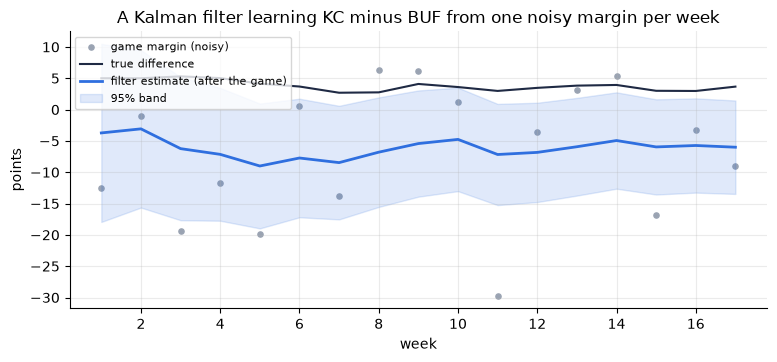

In [4]:
rng = np.random.default_rng(7)
weeks, q, sigma = 17, 0.5, 13.0
true = np.cumsum(np.r_[5.0, rng.normal(0, np.sqrt(2 * q), weeks - 1)])   # true difference, drifting
margins = true + rng.normal(0, sigma, weeks)
r = toy_filter(margins, q=q, sigma=sigma)
diff = r["KC"] - r["BUF"]
sd = np.sqrt(r["sd_KC"] ** 2 * 2 * (1 - r["corr"]))
fig, ax = plt.subplots()
ax.scatter(r["week"], margins, s=14, color=MUTED, label="game margin (noisy)")
ax.plot(r["week"], true, color=INK, lw=1.5, label="true difference")
ax.plot(r["week"], diff, color=ACCENT, lw=2, label="filter estimate (after the game)")
ax.fill_between(r["week"], diff - 2 * sd, diff + 2 * sd, color=ACCENT, alpha=0.15, label="95% band")
ax.set_xlabel("week"); ax.set_ylabel("points"); ax.legend(loc="upper left", fontsize=8)
ax.set_title("A Kalman filter learning KC minus BUF from one noisy margin per week"); plt.show()

### A second measurement: EPA margin

Point margins are noisy because of fumble luck, field goals that doink, and garbage-time scores. A game's EPA
margin (home offense EPA per play minus away offense EPA per play) measures the same thing with less of that
luck. M3b feeds the filter both, per game:

```
margin            = d + h + e_m        (e_m: SD sigma_m)
scale * EPA margin = d     + e_e        (e_e: SD sigma_e)
corr(e_m, e_e) = rho                   (they share some of the game's luck)
```

where `d` is the strength difference and `scale` converts EPA per play into points. The EPA margin is raw, not
opponent-adjusted: the filter does the opponent adjustment itself, because each measurement is about the
*difference* between the two teams that met. Feeding a pre-adjusted margin would count the opponent twice.

How much does the second measurement help? That depends on its noise and on how correlated it is with the first.
With the tuned values (next section), one game's uncertainty about `d` drops like this:

In [5]:
T = kf.TUNED
prior_var = 2 * 20.0                           # two teams, each with variance about 20 points^2 mid-season
R = np.array([[T.sigma_m ** 2, T.rho * T.sigma_m * T.sigma_e], [T.rho * T.sigma_m * T.sigma_e, T.sigma_e ** 2]])
one = np.ones(2)
S = prior_var * np.outer(one, one) + R          # covariance of the two measurements before the game
margin_only = prior_var - prior_var ** 2 / (prior_var + T.sigma_m ** 2)
both = prior_var - (prior_var * one) @ np.linalg.solve(S, prior_var * one)
print(f"variance of d before the game: {prior_var:.1f}; after margin only: {margin_only:.1f}; "
      f"after margin and EPA: {both:.1f}")
print(f"the EPA measurement is worth {100 * (margin_only - both) / (prior_var - margin_only):.0f}% more "
      "information than the margin alone")

variance of d before the game: 40.0; after margin only: 31.7; after margin and EPA: 31.5
the EPA measurement is worth 3% more information than the margin alone


## 2. The real filter

**State.** One strength per franchise (32) plus home field, with a full 33 x 33 covariance. Home field is a
slowly drifting state rather than a constant, because the home edge has fallen from about 3 points to about 1.5
since 2000; Elo v2 learns it online for the same reason. One strength per team, not offense and defense: both
measurements are margins, which only see the difference, so a split could not be identified.

**As of.** Each week, the filter first predicts every game of the week from the state before any of them is
played, then absorbs the week's results. A Thursday result never reaches that Sunday's prediction. The leakage
check (scramble everything from a game's `as_of` on and rebuild) passes on synthetic and real data, and a
deliberately leaky version (the post-week margin) fails it.

**Tuning.** Eight knobs, fit by maximum likelihood on 2000-2005 (1999 is burn-in), so the development seasons
never touch them. The objective is the joint density of each game's two measurements under its pre-week forecast.
The margin-only likelihood cannot pin down the EPA measurement's scale, noise, and correlation: different starting
points land in different places along a flat ridge (log likelihoods within 7 units over 1,586 games). The joint
likelihood gives the same answer from all four starts, and its margin-only likelihood is within 3 units of the
best margin-only fit.

In [6]:
k = tune["kalman"]
c = k["config"]
print("tuned settings:")
words = {"q_week": "weekly drift variance (points^2)", "gamma": "between-season reversion (mean multiplied by)",
         "q_season": "off-season variance added (points^2)", "sigma_m": "margin noise SD (points)",
         "sigma_e": "EPA-measurement noise SD (points)", "rho": "correlation of the two noises",
         "scale": "points per EPA-per-play margin", "q_hfa": "home-field drift variance per week",
         "epa_home": "league home EPA edge per play (fixed, 1999-2005)"}
for key, w in words.items():
    print(f"  {key:<9} {c[key]:>10.5g}   {w}")
print(f"\nmargin log likelihood per game {k['loglik_per_game']:.4f} vs {k['loglik_constant_per_game']:.4f} for a "
      f"constant forecast; RMSE {k['rmse']:.2f} vs {k['rmse_constant']:.2f} points ({k['n_games']} games, 2000-2005)")
print("starts (joint, margin log likelihood):", [(round(s['joint'], 1), round(s['margin'], 1)) for s in k["starts"]])

tuned settings:
  q_week       0.72158   weekly drift variance (points^2)
  gamma        0.48317   between-season reversion (mean multiplied by)
  q_season      14.431   off-season variance added (points^2)
  sigma_m       12.361   margin noise SD (points)
  sigma_e        13.52   EPA-measurement noise SD (points)
  rho          0.80709   correlation of the two noises
  scale         39.921   points per EPA-per-play margin
  q_hfa     0.00034383   home-field drift variance per week
  epa_home   0.0085843   league home EPA edge per play (fixed, 1999-2005)

margin log likelihood per game -4.0155 vs -4.0921 for a constant forecast; RMSE 13.42 vs 14.49 points (1586 games, 2000-2005)
starts (joint, margin log likelihood): [(-6072.2, -6368.9), (-6071.9, -6368.6), (-6071.9, -6368.6), (-6071.9, -6368.8)]


In words: a team's strength drifts about 0.85 points per week (3.5 points over a season), and each off-season
it keeps about half of its distance from average (gamma 0.48) plus about 3.8 points of new noise. A game's
margin has about 12.4 points of noise. Home field barely drifts (about 0.08 points per season), so in practice it
is a slowly updated estimate.

### Team strength over time

Run the filter from 1999 through 2019 and look at a few teams. The band is plus or minus one SD of the filter's
own uncertainty: wide each September, narrower by December.

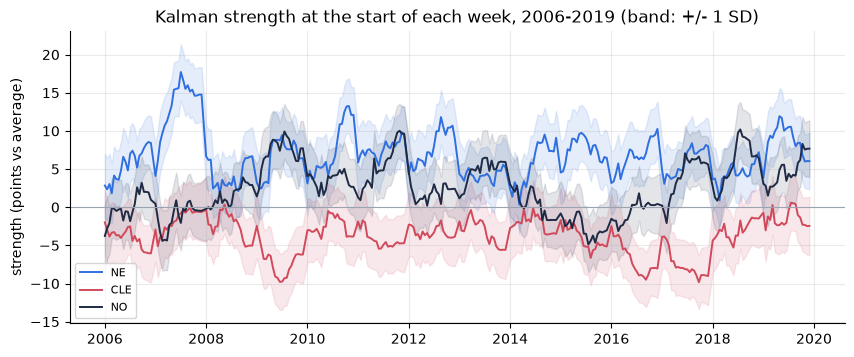

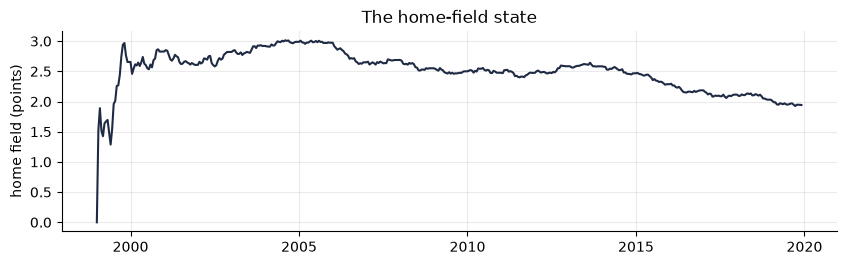

In [7]:
years = range(1999, 2020)
pbp = D.load_pbp(years, columns=["game_id", "posteam", "defteam", "play_type", "pass", "rush", "epa", "success",
                                  "wp", "two_point_attempt"])
sched = asof.add_asof(D.load_schedules(years))
gt = kf.game_table(pbp, sched, kf.TUNED)
res = kf.run_filter(gt, kf.TUNED, snapshots=True)
snap = pd.DataFrame([{"season": s, "week": w, **{t: x[i] for i, t in enumerate(kf.TEAMS)}, "hfa": x[-1],
                      **{f"sd_{t}": np.sqrt(d[i]) for i, t in enumerate(kf.TEAMS)}} for s, w, x, d in res.snapshots])
snap["t"] = snap["season"] + (snap.groupby("season").cumcount()) / 22
fig, ax = plt.subplots(figsize=(10, 3.8))
for team, col in (("NE", ACCENT), ("CLE", BAD), ("NO", INK)):
    s_ = snap[snap["season"] >= 2006]
    ax.plot(s_["t"], s_[team], color=col, lw=1.4, label=team)
    ax.fill_between(s_["t"], s_[team] - s_[f"sd_{team}"], s_[team] + s_[f"sd_{team}"], color=col, alpha=0.12)
ax.axhline(0, color=MUTED, lw=0.8)
ax.set_ylabel("strength (points vs average)"); ax.legend(fontsize=8, loc="lower left")
ax.set_title("Kalman strength at the start of each week, 2006-2019 (band: +/- 1 SD)"); plt.show()

fig, ax = plt.subplots(figsize=(10, 2.6))
ax.plot(snap["t"], snap["hfa"], color=INK)
ax.set_ylabel("home field (points)"); ax.set_title("The home-field state"); plt.show()

### How it scores on its own

As a standalone forecaster the filter says P(home win) = Phi(kf_margin / sqrt(kf_sd^2 + sigma_m^2)): the
predicted margin, divided by its total uncertainty, through the normal curve. No logistic regression, no QB
term. On the development games it beats Elo, the filter's direct competitor (one rating per team, built from
results), by 0.0011 Brier (the interval includes zero).

In [8]:
def row(name):
    m = runs[name]["metrics"]; c = runs[name]["comparisons"]["vs_a4s"]; e = runs[name]["comparisons"]["vs_elo"]
    return {"step": name, "brier": m["brier"], "logloss": m["logloss"], "acc": m["accuracy"], "ece": m["ece"],
            "vs A4s": f"{c['diff']:+.4f} [{c['ci_low']:+.4f}, {c['ci_high']:+.4f}]",
            "vs Elo": f"{e['diff']:+.4f} [{e['ci_low']:+.4f}, {e['ci_high']:+.4f}]"}
elo_b = float(np.mean((dev["y"] - dev["p_elo_v2"]) ** 2))
print(f"Elo v2 on the same games: {elo_b:.4f}")
pd.DataFrame([row(s) for s in ("KF", "C2k", "A4s")]).set_index("step").round(4)

Elo v2 on the same games: 0.2178


,brier,logloss,acc,ece,vs A4s,vs Elo
step,,,,,,
KF,0.2167,0.6236,0.6455,0.0168,"+0.0016 [-0.0004, +0.0036]","-0.0011 [-0.0029, +0.0007]"
C2k,0.2167,0.6235,0.6475,0.0148,"+0.0016 [-0.0005, +0.0035]","-0.0011 [-0.0030, +0.0007]"
A4s,0.2151,0.6197,0.6469,0.0114,"+0.0000 [+0.0000, +0.0000]","-0.0027 [-0.0043, -0.0011]"


Where does that edge come from? Not from EPA. Section 1 showed that, with the tuned noise levels, one game's
EPA margin adds only about 3% to what its point margin already says: the two share most of the game's luck
(correlation 0.81) and the EPA version is no less noisy once converted to points. Switching the EPA measurement
off entirely (a descriptive check, not a ladder step) leaves the standalone score unchanged. The filter's edge
over Elo is its structure: a step size that grows when the ratings are uncertain (September) and shrinks when
they are not, and a stronger pull toward average between seasons (it keeps about half of a team's distance from
average; Elo v2 keeps 60%).

In [9]:
from dataclasses import replace
off = replace(kf.TUNED, sigma_e=1e4, rho=0.0)
for name, cfg_ in (("tuned (margin + EPA)", kf.TUNED), ("EPA measurement off", off)):
    r_ = kf.run_filter(gt, cfg_)
    m_ = pd.Series(r_.pred_mean, index=gt["game_id"]).loc[dev["game_id"]].to_numpy()
    v_ = pd.Series(r_.pred_var, index=gt["game_id"]).loc[dev["game_id"]].to_numpy()
    p_ = kf.win_prob(m_, np.sqrt(v_), cfg_.sigma_m)
    print(f"{name:<22} standalone Brier on DEV {np.mean((dev['y'] - p_) ** 2):.4f}")

tuned (margin + EPA)   standalone Brier on DEV 0.2167
EPA measurement off    standalone Brier on DEV 0.2165


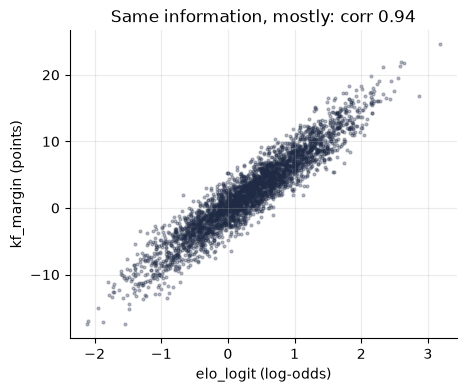

In [10]:
fig, ax = plt.subplots(figsize=(5, 4))
ax.scatter(dev["elo_logit"], dev["kf_margin"], s=4, alpha=0.3, color=INK)
ax.set_xlabel("elo_logit (log-odds)"); ax.set_ylabel("kf_margin (points)")
ax.set_title(f"Same information, mostly: corr {np.corrcoef(dev['elo_logit'], dev['kf_margin'])[0, 1]:.2f}")
plt.show()

## 3. Week-varying weights (C1)

A4s uses the same weights all season. The No-Elo study found Elo's weight falls from about 1.0 in weeks 1-4 to
about 0.7 late, while EPA's rises. C1 lets the weights move with two interactions:

```
early = max(0, 1 - (week - 1) / w0)          1 in week 1, falling to 0 by week w0 + 1
logit p = A4s terms + b1 * elo_logit * early + b2 * adj_epa_margin * early
```

`w0` is the one knob M3b tunes on the development seasons themselves (grid below), so C1's development score is
slightly optimistic.

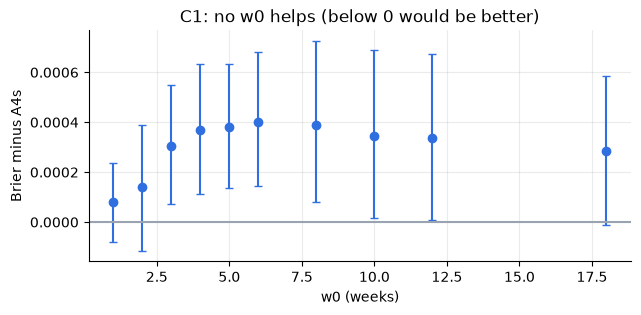

,w0,brier,minus A4s,CI low,CI high
0,1.0,0.21517,0.00008,-0.00008,0.00024
1,2.0,0.21523,0.00014,-0.00012,0.00039
2,3.0,0.21539,0.00031,0.00007,0.00055
3,4.0,0.21546,0.00037,0.00011,0.00063
4,5.0,0.21547,0.00038,0.00014,0.00063
5,6.0,0.21549,0.00040,0.00014,0.00068
6,8.0,0.21547,0.00039,0.00008,0.00073
7,10.0,0.21543,0.00035,0.00001,0.00069
8,12.0,0.21542,0.00034,0.00001,0.00067
9,18.0,0.21537,0.00028,-0.00001,0.00059


In [11]:
g = pd.DataFrame(runs["C1"]["c1_grid"])
g["minus A4s"] = [c["diff"] for c in g["vs_a4s"]]
g["CI low"] = [c["ci_low"] for c in g["vs_a4s"]]
g["CI high"] = [c["ci_high"] for c in g["vs_a4s"]]
fig, ax = plt.subplots(figsize=(7, 3))
ax.errorbar(g["w0"], g["minus A4s"], yerr=[g["minus A4s"] - g["CI low"], g["CI high"] - g["minus A4s"]], fmt="o",
            color=ACCENT, capsize=3)
ax.axhline(0, color=MUTED); ax.set_xlabel("w0 (weeks)"); ax.set_ylabel("Brier minus A4s")
ax.set_title("C1: no w0 helps (below 0 would be better)"); plt.show()
g[["w0", "brier", "minus A4s", "CI low", "CI high"]].round(5)

Nothing helps. The best `w0` is 1 (only week 1 gets its own weights), and even that is no better than A4s. The
weight shift the No-Elo study saw is real but small and noisy: the early-season coefficients in the refits swing
in sign from season to season, so letting them move adds estimation noise that costs as much as it gains.
A4s's early-season weakness is not about weights; it is that nobody, A4s included, knows much in September.

## 4. A better QB term (C3)

A4s's QB term is the difference between this week's starter's value and the QB play the team's rating
remembers. Three ideas to improve the value, each tuned on a QB target (next game's EPA per dropback), not on
game outcomes, and each scored as A4s with only the QB value swapped:

- **(a) CPOE composite.** value = EPA value + w x (CPOE value - replacement CPOE). CPOE exists from 2006, so w and
  the CPOE shrinkage are tuned on 2007-2008.
- **(b) Experience prior.** Instead of shrinking every QB toward rookie replacement level, shrink toward a level
  that depends on career dropbacks (4 buckets), tuned on 2000-2005. **Draft round is not used**: the nflverse
  players table takes its draft fields from Pro-Football-Reference (nflverse-players `CONTRIBUTING.md`), and this
  project avoids PFR-derived data.
- **(c) Aging.** A piecewise-linear age curve moves the data part of a QB's value from the average age of his
  past dropbacks to his age now (birth dates: nflverse players table, GSIS basic information, CC BY).
- **(d)** is (b) re-tuned only on starter-games where the starter changed from the team's previous game, the
  games the prior is for. It was added after (b) scored worse on the development games, and is labelled so.

In [12]:
q = tune["qb"]
print(f"(a) CPOE: weight {q['cpoe']['cpoe_weight']} EPA/dropback per CPOE point, k {q['cpoe']['cpoe_k']:g} attempts; "
      f"QB-target wMSE {q['cpoe']['wmse']:.5f} vs {q['cpoe']['base_wmse']:.5f} ({q['cpoe']['n_games']} starter-games, 2007-08)")
print(f"(b) experience offsets by career dropbacks {q['experience']['edges']}: {q['experience']['offsets']}; "
      f"wMSE {q['experience']['wmse']:.5f} vs {q['experience']['base_wmse']:.5f}")
print(f"(c) aging (peak, slope before, slope after) {q['aging']['curve']}; wMSE {q['aging']['wmse']:.5f} vs "
      f"{q['aging']['base_wmse']:.5f}")
print(f"(d) experience offsets on {q['experience_changed']['n_games']} changed-starter games: "
      f"{q['experience_changed']['offsets']}; wMSE {q['experience_changed']['wmse']:.5f} vs "
      f"{q['experience_changed']['base_wmse']:.5f}")

(a) CPOE: weight 0.01 EPA/dropback per CPOE point, k 400 attempts; QB-target wMSE 0.11457 vs 0.11490 (1024 starter-games, 2007-08)
(b) experience offsets by career dropbacks [0, 100, 500, 2000]: [-0.0541, 0.0159, 0.1412, 0.0648]; wMSE 0.10839 vs 0.10918
(c) aging (peak, slope before, slope after) [31.0, 0.14, 0.0]; wMSE 0.10810 vs 0.10918
(d) experience offsets on 351 changed-starter games: [-0.0651, 0.08, 0.0329, 0.0318]; wMSE 0.11445 vs 0.11588


In [13]:
rows = []
for s in ("A4s", "C3a", "C3b", "C3c", "C3d", "C3abc"):
    r = runs[s]; sp = r["splits"]
    rows.append({"step": s, "brier": r["metrics"]["brier"],
                 "vs A4s": r["comparisons"]["vs_a4s"]["diff"],
                 "changed n": sp["changed"]["n"], "changed brier": sp["changed"]["brier"],
                 "changed vs A4s": sp["changed"]["vs_a4s"]["diff"],
                 "changed CI": f"[{sp['changed']['vs_a4s']['ci_low']:+.4f}, {sp['changed']['vs_a4s']['ci_high']:+.4f}]",
                 "market (changed)": sp["changed"]["brier_market"]})
pd.DataFrame(rows).set_index("step").round(4)

,brier,vs A4s,changed n,changed brier,changed vs A4s,changed CI,market (changed)
step,,,,,,,
A4s,0.2151,0.0000,664,0.2150,0.0000,"[+0.0000, +0.0000]",0.2072
C3a,0.2150,-0.0000,664,0.2151,0.0001,"[-0.0003, +0.0006]",0.2072
C3b,0.2157,0.0006,664,0.2177,0.0027,"[+0.0001, +0.0052]",0.2072
C3c,0.2155,0.0004,664,0.2157,0.0007,"[-0.0007, +0.0021]",0.2072
C3d,0.2152,0.0001,664,0.2152,0.0002,"[-0.0019, +0.0023]",0.2072
C3abc,0.2161,0.0010,664,0.2181,0.0031,"[+0.0004, +0.0056]",0.2072


Every QB extra improves the QB target it was tuned on, and none of them improves game predictions:

- **CPOE (a)** changes almost nothing (its delta correlates 0.996 with A4s's).
- **Experience (b)** makes changed-starter games *worse*. Tuned on all starter-games, which are mostly
  established starters, it raises the prior for mid-career QBs by about 0.14 EPA per dropback, so a veteran
  backup looks less bad than he plays. Re-tuned on the changed-starter games (d), it does no harm but no good.
- **Aging (c)** wants an implausibly steep curve (+0.14 EPA per dropback per year before 31): it is absorbing
  young QBs improving faster than the rating's 48-week memory allows, not aging. It hurts slightly.

The gap to the market on changed-starter games (about 0.008) is not about how the backup's value is estimated
from his own dropbacks. The market knows things the play-by-play does not: practice reports, the coach's plan,
and how hurt the starter really is.

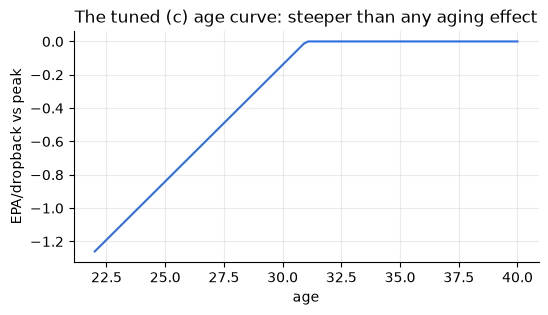

In [14]:
age = np.linspace(22, 40, 100)
peak, before, after = q["aging"]["curve"]
F = before * (np.minimum(age, peak) - peak) + after * (np.maximum(age, peak) - peak)
fig, ax = plt.subplots(figsize=(6, 3))
ax.plot(age, F, color=ACCENT); ax.set_xlabel("age"); ax.set_ylabel("EPA/dropback vs peak")
ax.set_title("The tuned (c) age curve: steeper than any aging effect"); plt.show()

## 5. The ladder and the pick

Every step uses A4s's protocol: logistic regression refit each season on REG games from 2001, older seasons
down-weighted, features as of the start of the game's week, the starter's identity treated as known (M3-D1).
Confidence intervals are paired against A4s on the same 3,450 games (2,000 bootstrap replicates). The ECE check
is one-sided: a model fails only if its ECE is above the 95th percentile a perfectly calibrated forecaster shows
at this sample size. **C2d** (Elo plus `kf_margin`, without the ridge EPA margin) was added to the spec's C2a-c
because C2b's EPA coefficient turned negative once `kf_margin` (which already reads EPA) was in the model.

In [15]:
order = ["A4s", "A4bs", "C1", "C2a", "C2b", "C2c", "C2d", "C2k", "KF", "C3a", "C3b", "C3c", "C3d", "C3abc"]
order += [s for s in runs if s.startswith("C4")] + [s for s in runs if s.endswith("_last")]
tab = []
for s in order:
    r = runs[s]; m = r["metrics"]; c = r["comparisons"]["vs_a4s"]
    tab.append({"step": s, "brier": m["brier"], "logloss": m["logloss"], "acc": m["accuracy"], "ece": m["ece"],
                "ece ok": m["ece_pass"], "vs A4s": c["diff"], "CI low": c["ci_low"], "CI high": c["ci_high"],
                "1SE": (r.get("one_se") or {}).get("within"), "chosen": (r.get("one_se") or {}).get("chosen")})
tab = pd.DataFrame(tab).set_index("step")
tab.round(4)

,brier,logloss,acc,ece,ece ok,vs A4s,CI low,CI high,1SE,chosen
step,,,,,,,,,,
A4s,0.2151,0.6197,0.6469,0.0114,True,0.0000,0.0000,0.0000,False,False
A4bs,0.2172,0.6244,0.6434,0.0116,True,0.0021,0.0010,0.0033,None,False
C1,0.2152,0.6199,0.6472,0.0126,True,0.0001,-0.0001,0.0002,False,False
C2a,0.2146,0.6186,0.6539,0.0187,True,-0.0005,-0.0020,0.0010,False,False
C2b,0.2141,0.6175,0.6492,0.0130,True,-0.0009,-0.0019,0.0001,True,False
C2c,0.2145,0.6185,0.6510,0.0226,True,-0.0006,-0.0021,0.0010,False,False
C2d,0.2141,0.6175,0.6495,0.0142,True,-0.0010,-0.0019,0.0000,True,True
C2k,0.2167,0.6235,0.6475,0.0148,True,0.0016,-0.0005,0.0035,False,False
KF,0.2167,0.6236,0.6455,0.0168,True,0.0016,-0.0004,0.0036,None,False


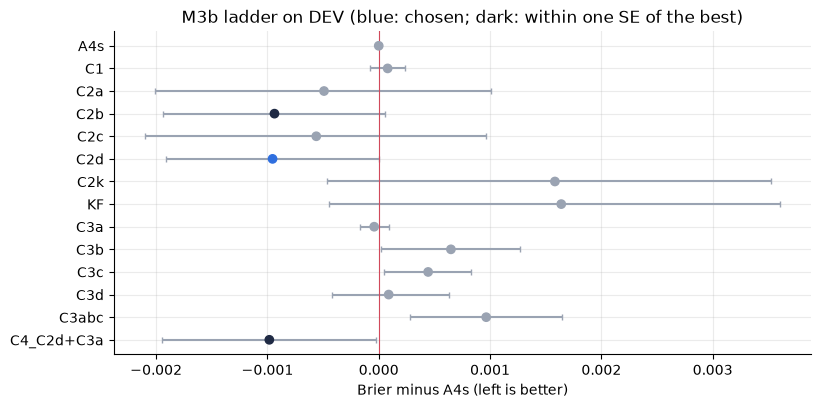

In [16]:
fig, ax = plt.subplots(figsize=(9, 4.2))
t2 = tab.drop(index=[s for s in tab.index if s.endswith("_last") or s == "A4bs"])
y_ = np.arange(len(t2))[::-1]
cols = [ACCENT if ch else (INK if w else MUTED) for ch, w in zip(t2["chosen"].fillna(False), t2["1SE"].fillna(False))]
ax.errorbar(t2["vs A4s"], y_, xerr=[t2["vs A4s"] - t2["CI low"], t2["CI high"] - t2["vs A4s"]], fmt="none",
            ecolor=MUTED, capsize=2)
ax.scatter(t2["vs A4s"], y_, color=cols, zorder=3)
ax.axvline(0, color=BAD, lw=0.8)
ax.set_yticks(y_); ax.set_yticklabels(t2.index); ax.set_xlabel("Brier minus A4s (left is better)")
ax.set_title("M3b ladder on DEV (blue: chosen; dark: within one SE of the best)"); plt.show()

In [17]:
best = next(s for s, r in runs.items() if r.get("one_se", {}).get("best") == s)
chosen = next(s for s, r in runs.items() if r.get("one_se", {}).get("chosen"))
print(f"best DEV Brier: {best}; within one SE: {runs[chosen]['one_se']['eligible']}; chosen (simplest): {chosen}")
c = runs[chosen]["comparisons"]["vs_a4s"]
print(f"{chosen} minus A4s: {c['diff']:+.5f} [{c['ci_low']:+.5f}, {c['ci_high']:+.6f}]  -> the interval "
      f"{'excludes' if c['ci_high'] < 0 else 'just includes'} zero")
sp = pd.DataFrame({k: {"n": v["n"], "chosen": v["brier"], "A4s": v["brier_a4s"], "market": v["brier_market"],
                       "minus A4s": v["vs_a4s"]["diff"],
                       "CI": f"[{v['vs_a4s']['ci_low']:+.4f}, {v['vs_a4s']['ci_high']:+.4f}]"}
                   for k, v in runs[chosen]["splits"].items()}).T
sp

best DEV Brier: C4_C2d+C3a; within one SE: ['C2b', 'C2d', 'C4_C2d+C3a']; chosen (simplest): C2d
C2d minus A4s: -0.00095 [-0.00191, +0.000001]  -> the interval just includes zero


,n,chosen,A4s,market,minus A4s,CI
weeks_1_4,751,0.22371,0.224282,0.21984,-0.000573,"[-0.0023, +0.0011]"
weeks_5_9,969,0.212399,0.212562,0.209525,-0.000163,"[-0.0019, +0.0016]"
weeks_10_18,1730,0.210945,0.212507,0.207188,-0.001562,"[-0.0029, -0.0002]"
changed,664,0.214979,0.214993,0.207218,-0.000014,"[-0.0021, +0.0021]"
unchanged,2786,0.21393,0.215108,0.211404,-0.001178,"[-0.0022, -0.0001]"


In [18]:
co = pd.DataFrame(runs[chosen]["coefficients"])
print(co.round(3).to_string(index=False))
sd = dev[["elo_logit", "kf_margin", "qb_delta_diff"]].std()
last = co.iloc[-1]
print(f"\n2019 model, per 1 SD of each feature (log-odds): elo_logit {last['elo_logit'] * sd['elo_logit']:+.2f}, "
      f"kf_margin {last['kf_margin'] * sd['kf_margin']:+.2f}, qb_delta_diff {last['qb_delta_diff'] * sd['qb_delta_diff']:+.2f}")

 season  n_train  intercept  elo_logit  kf_margin  qb_delta_diff
   2006     1272     -0.016      0.296      0.094          2.890
   2007     1528     -0.049      0.429      0.068          2.936
   2008     1784     -0.051      0.366      0.082          3.086
   2009     2040     -0.048      0.397      0.079          3.320
   2010     2296     -0.046      0.431      0.077          3.263
   2011     2552     -0.043      0.352      0.084          2.592
   2012     2808     -0.049      0.263      0.099          2.721
   2013     3064     -0.046      0.203      0.108          2.819
   2014     3320     -0.030      0.176      0.114          3.202
   2015     3576     -0.037      0.269      0.105          3.144
   2016     3832     -0.045      0.369      0.089          3.163
   2017     4088     -0.033      0.496      0.073          3.192
   2018     4344     -0.031      0.487      0.076          3.665
   2019     4600     -0.014      0.433      0.083          3.495

2019 model, per 1 SD of 

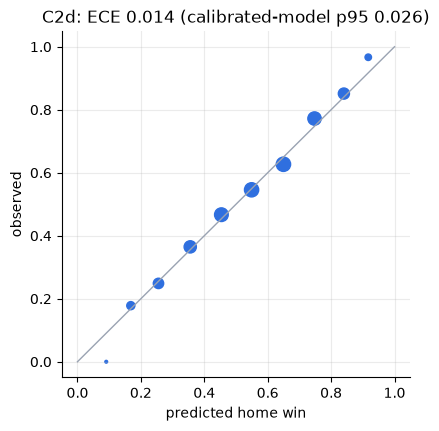

In [19]:
p = dev[f"p_{chosen}"].to_numpy(); y = dev["y"].to_numpy()
t = calibration.reliability_table(y, p)
fig, ax = plt.subplots(figsize=(4.5, 4.5))
ax.plot([0, 1], [0, 1], color=MUTED, lw=1)
ax.scatter(t["mean_pred"], t["observed"], s=np.sqrt(t["n"]) * 4, color=ACCENT)
ax.set_xlabel("predicted home win"); ax.set_ylabel("observed")
null = calibration.ece_null_range(p)
ax.set_title(f"{chosen}: ECE {calibration.ece(y, p):.3f} (calibrated-model p95 {null['p95']:.3f})"); plt.show()

## 6. What it adds up to

- **The Kalman filter is the one real gain**, and it comes from the filter's structure, not from EPA (the EPA
  measurement adds almost nothing). On its own it beats Elo (0.2167 vs 0.2178, not significant). Inside the model,
  swapping the ridge EPA margin for `kf_margin` (C2d) improves A4s by about 0.001 Brier, with a 95% interval that
  touches zero ([-0.0019, +0.0000]); every coefficient keeps its sign in all 14 refits. The gain is in weeks 10-18
  and in games where the starter did not change. It does not touch the two weaknesses that motivated M3b.
- **The early season is not fixed** by week-varying weights (C1) or by the filter (C2d weeks 1-4: -0.0006, noise).
- **The changed-starter gap is not fixed** by a better QB value: CPOE, experience, and aging each improve the QB
  target they were tuned on, and none improves game predictions.
- **By the spec's acceptance rule (CI excludes zero), M3b does not pass on DEV**, narrowly. The one-SE pick
  is C2d. A holdout pre-registration for C2d is written in `context/ml.md`; whether to spend the one holdout run
  on a model that did not clear DEV is Walker's call.